In [ ]:
import pandas as pd; import numpy as np
from matplotlib import pyplot as plt; import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, precision_recall_curve, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score
import warnings; warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('bank_note_authenticity.csv');
df.sample(2)

,variance,skewness,curtosis,entropy,class
52,3.1452,5.825000,-0.51439,-1.49440,0
374,-1.5055,0.070346,6.86810,-0.50648,0


In [ ]:
df.shape

(1372, 5)

In [ ]:
df['class'].mean()

0.4446064139941691

In [ ]:
X = df.drop('class', axis = 1); y = df['class']

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 0)

# Task 1
### Decision Tree Model 1
- Train a decision tree classifier with default settings using a fixed random state on the training data and visualise the learned tree structure and extract and display the number of leaf nodes and the maximum depth of the trained decision tree
- Generate and compare confusion matrices for the trained decision tree on the training and validation datasets
- Generate class predictions for both the training and validation datasets using the trained decision tree
- Compute accuracy and sensitivity (recall) for training and validation predictions and summarise the results in a metrics table

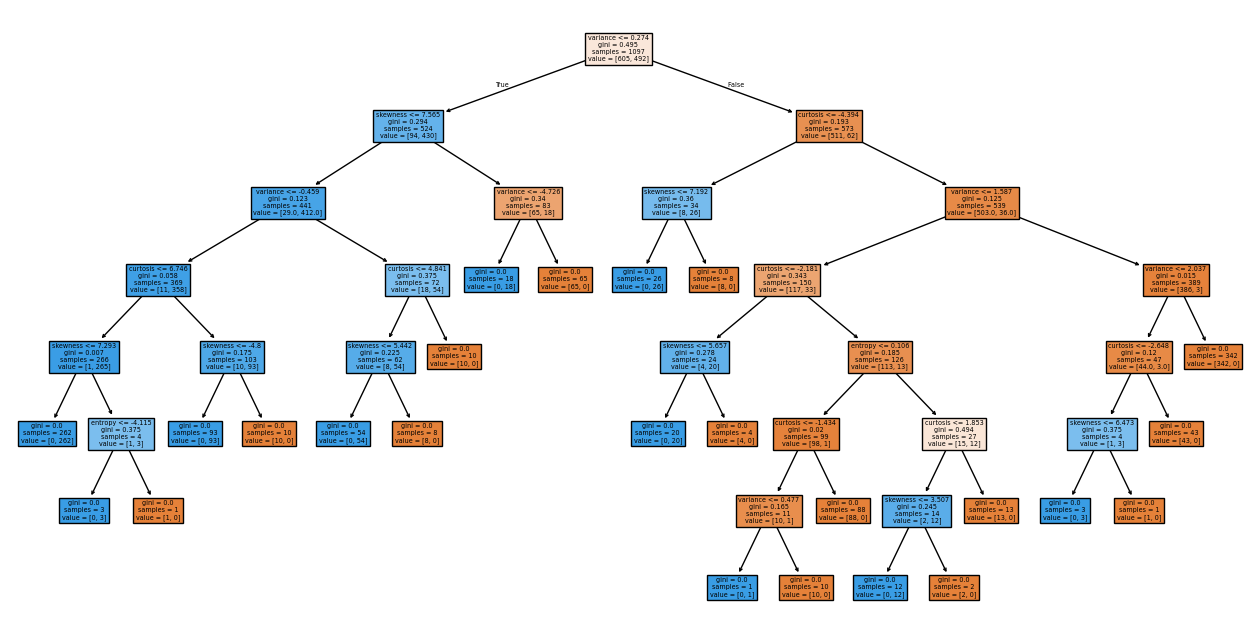

In [ ]:
tree_model_1 = DecisionTreeClassifier(random_state = 0); tree_model_1 = tree_model_1.fit(X_train, y_train)
fig = plt.figure(figsize = (16, 8)); fig = tree.plot_tree(tree_model_1, feature_names = X.columns, filled = True)

In [ ]:
tree_model_1_n_leaves = tree_model_1.get_n_leaves(); tree_model_1_depth = tree_model_1.get_depth()
print('Number of leaves =', tree_model_1_n_leaves); print('Tree depth =', tree_model_1_depth)

Number of leaves = 24
Tree depth = 7


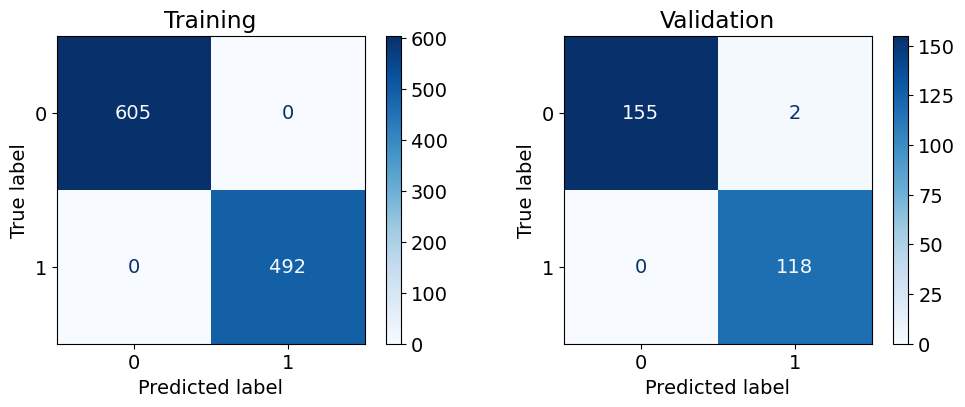

In [ ]:
plt.rcParams.update({'font.size': 14}); fig, ax = plt.subplots(1, 2, figsize = (12, 4))
ConfusionMatrixDisplay.from_estimator(tree_model_1, X_train, y_train, cmap = plt.cm.Blues, ax = ax[0])
ConfusionMatrixDisplay.from_estimator(tree_model_1, X_val, y_val, cmap = plt.cm.Blues, ax = ax[1])
ax[0].set_title('Training'); ax[1].set_title('Validation');

In [ ]:
y_pred_1_train = tree_model_1.predict(X_train); y_pred_1_val = tree_model_1.predict(X_val)
acc_train_1 = accuracy_score(y_train, y_pred_1_train); acc_val_1 = accuracy_score(y_val, y_pred_1_val)
sens_train_1 = recall_score(y_train, y_pred_1_train); sens_val_1 = recall_score(y_val, y_pred_1_val)
tree_model_1_metrics = pd.DataFrame(data = {'Accuracy': [acc_train_1, acc_val_1],
                                            'Sensitivity': [sens_train_1, sens_val_1]},
                                    index = ['tree_model_1_train', 'tree_model_1_val'])
tree_model_1_metrics

,Accuracy,Sensitivity
tree_model_1_train,1.000000,1.0
tree_model_1_val,0.992727,1.0


# Task 2
### Decision Tree Model 2
- Tune the decision tree classifier for maximum depth and minimum number of samples in leaf node, with all other settings as default (use the same random state)
- Visualise the learned tree structure and extract and display the number of leaf nodes and the maximum depth of the tuned decision tree
- Generate and compare confusion matrices for the tuned decision tree on the training and validation datasets
- Generate class predictions for both the training and validation datasets using the tuned decision tree
- Compute accuracy and sensitivity (recall) for training and validation predictions and summarise the results in a metrics table

In [ ]:
param_grid = {'max_depth': [2, 4, 6], 'min_samples_leaf': [5, 10, 15]}
tree_model_gscv = DecisionTreeClassifier(random_state = 0)
tree_model_2 = GridSearchCV(estimator = tree_model_gscv, param_grid = param_grid, scoring = 'recall', cv = 5, verbose = 3)
tree_model_2.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END ...max_depth=2, min_samples_leaf=5;, score=0.879 total time=   0.0s
[CV 2/5] END ...max_depth=2, min_samples_leaf=5;, score=0.727 total time=   0.0s
[CV 3/5] END ...max_depth=2, min_samples_leaf=5;, score=0.847 total time=   0.0s
[CV 4/5] END ...max_depth=2, min_samples_leaf=5;, score=0.898 total time=   0.0s
[CV 5/5] END ...max_depth=2, min_samples_leaf=5;, score=0.816 total time=   0.0s
[CV 1/5] END ..max_depth=2, min_samples_leaf=10;, score=0.879 total time=   0.0s
[CV 2/5] END ..max_depth=2, min_samples_leaf=10;, score=0.727 total time=   0.0s
[CV 3/5] END ..max_depth=2, min_samples_leaf=10;, score=0.847 total time=   0.0s
[CV 4/5] END ..max_depth=2, min_samples_leaf=10;, score=0.898 total time=   0.0s
[CV 5/5] END ..max_depth=2, min_samples_leaf=10;, score=0.816 total time=   0.0s
[CV 1/5] END ..max_depth=2, min_samples_leaf=15;, score=0.879 total time=   0.0s
[CV 2/5] END ..max_depth=2, min_samples_leaf=15;,

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [2, 4, 6],
                         'min_samples_leaf': [5, 10, 15]},
             scoring='recall', verbose=3)

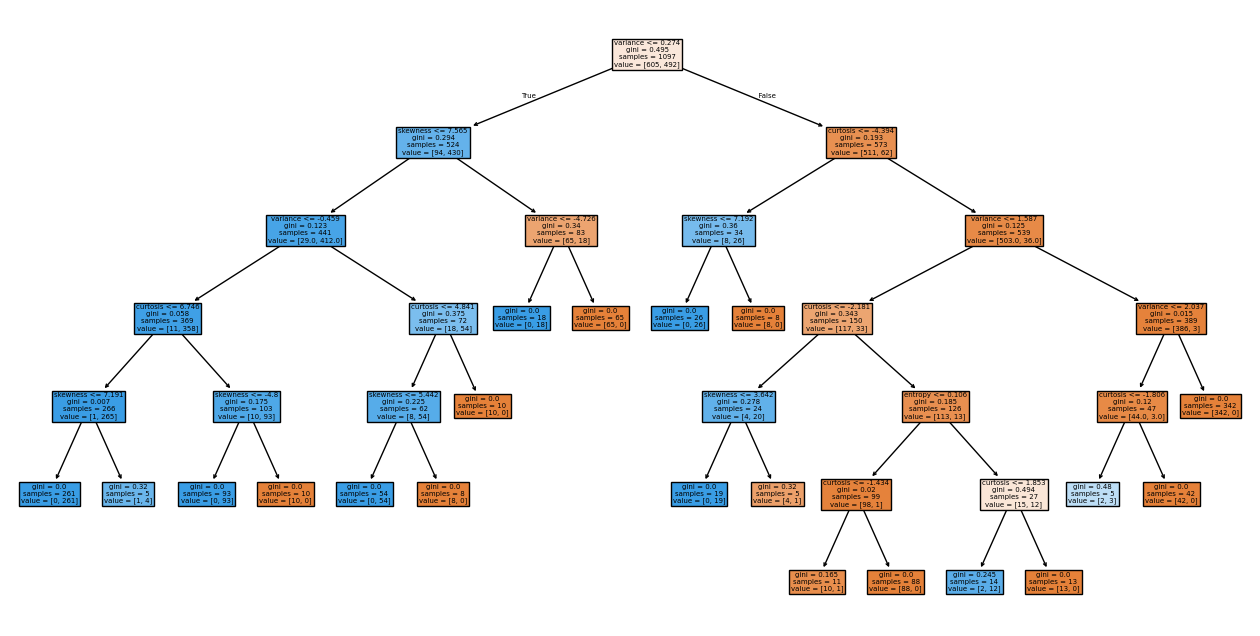

In [ ]:
fig = plt.figure(figsize = (16, 8)); fig = tree.plot_tree(tree_model_2.best_estimator_, feature_names = X.columns, filled = True)

In [ ]:
tree_model_2_n_leaves = tree_model_2.best_estimator_.get_n_leaves(); tree_model_2_depth = tree_model_2.best_estimator_.get_depth()
print('Number of leaves =', tree_model_2_n_leaves); print('Tree depth =', tree_model_2_depth)

Number of leaves = 20
Tree depth = 6


In [ ]:
y_pred_2_train = tree_model_2.best_estimator_.predict(X_train); y_pred_2_val = tree_model_2.best_estimator_.predict(X_val)
acc_train_2 = accuracy_score(y_train, y_pred_2_train); acc_val_2 = accuracy_score(y_val, y_pred_2_val)
sens_train_2 = recall_score(y_train, y_pred_2_train); sens_val_2 = recall_score(y_val, y_pred_2_val)
tree_model_2_metrics = pd.DataFrame(data = {'Accuracy': [acc_train_2, acc_val_2],
                                            'Sensitivity': [sens_train_2, sens_val_2]},
                                    index = ['tree_model_2_train', 'tree_model_2_val'])
tree_model_2_metrics

,Accuracy,Sensitivity
tree_model_2_train,0.993619,0.995935
tree_model_2_val,0.985455,0.983051


# Task 3
### Random Forest Model - 1
- Build a random forest model for the data with default parameters
- Visualize the confusion matrices for the training and validation sets

In [ ]:
rf1 = RandomForestClassifier(random_state = 0); rf1 = rf1.fit(X_train, y_train)

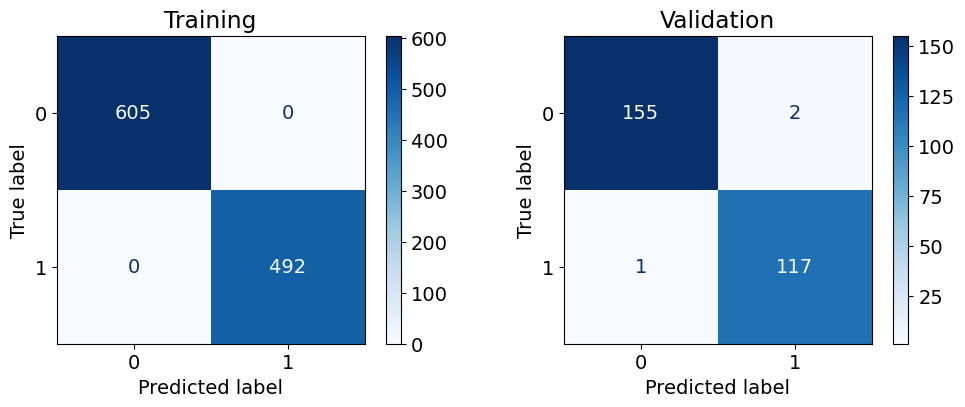

In [ ]:
plt.rcParams.update({'font.size': 14}); fig, ax = plt.subplots(1, 2, figsize = (12, 4))
ConfusionMatrixDisplay.from_estimator(rf1, X_train, y_train, cmap = plt.cm.Blues, ax = ax[0])
ConfusionMatrixDisplay.from_estimator(rf1, X_val, y_val, cmap = plt.cm.Blues, ax = ax[1])
ax[0].set_title('Training'); ax[1].set_title('Validation');

# Task 4
### Random Forest Model - 2
- Tune the random forest model on the number of estimators and max tree depth
- Print the optimal number of estimators and tree depth
- Visualize the confusion matrices for the training and validation sets

In [ ]:
rf_model = RandomForestClassifier(random_state = 0)
param_grid = {'n_estimators': np.arange(25, 125, 25), 'max_depth': [2, 4, 6]}
rf_gscv = GridSearchCV(estimator = rf_model, param_grid = param_grid, scoring = 'f1', cv = 5, verbose = 3)
rf2 = rf_gscv.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END ......max_depth=2, n_estimators=25;, score=0.948 total time=   0.0s
[CV 2/5] END ......max_depth=2, n_estimators=25;, score=0.904 total time=   0.0s
[CV 3/5] END ......max_depth=2, n_estimators=25;, score=0.935 total time=   0.0s
[CV 4/5] END ......max_depth=2, n_estimators=25;, score=0.959 total time=   0.0s
[CV 5/5] END ......max_depth=2, n_estimators=25;, score=0.883 total time=   0.0s
[CV 1/5] END ......max_depth=2, n_estimators=50;, score=0.938 total time=   0.0s
[CV 2/5] END ......max_depth=2, n_estimators=50;, score=0.915 total time=   0.0s
[CV 3/5] END ......max_depth=2, n_estimators=50;, score=0.905 total time=   0.0s
[CV 4/5] END ......max_depth=2, n_estimators=50;, score=0.948 total time=   0.0s
[CV 5/5] END ......max_depth=2, n_estimators=50;, score=0.896 total time=   0.0s
[CV 1/5] END ......max_depth=2, n_estimators=75;, score=0.932 total time=   0.0s
[CV 2/5] END ......max_depth=2, n_estimators=75;

In [ ]:
best_n_estimators = rf2.best_params_['n_estimators']; best_max_depth = rf2.best_params_['max_depth']
print('The optimal value of n_estimators is', best_n_estimators); print('The optimal value of max_depth is', best_max_depth)

The optimal value of n_estimators is 50
The optimal value of max_depth is 6


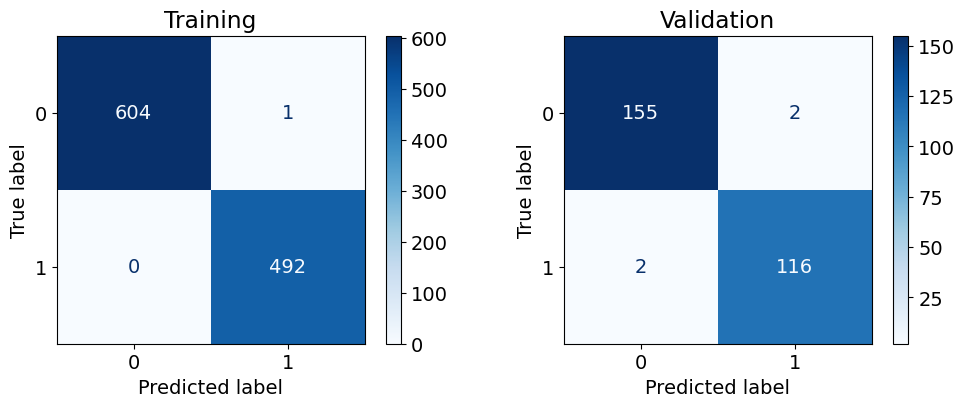

In [ ]:
plt.rcParams.update({'font.size': 14}); fig, ax = plt.subplots(1, 2, figsize = (12, 4))
ConfusionMatrixDisplay.from_estimator(rf2, X_train, y_train, cmap = plt.cm.Blues, ax = ax[0])
ConfusionMatrixDisplay.from_estimator(rf2, X_val, y_val, cmap = plt.cm.Blues, ax = ax[1])
ax[0].set_title('Training'); ax[1].set_title('Validation');

# Task 5
### Gradient Boosted Tree Model - 1
- Build a gradient boosted tree model for the data with the default parameters
- Visualise the confusion matrices for the training and validation sets

In [ ]:
gbt1 = AdaBoostClassifier(random_state = 0, algorithm = 'SAMME'); gbt1 = gbt1.fit(X_train, y_train)

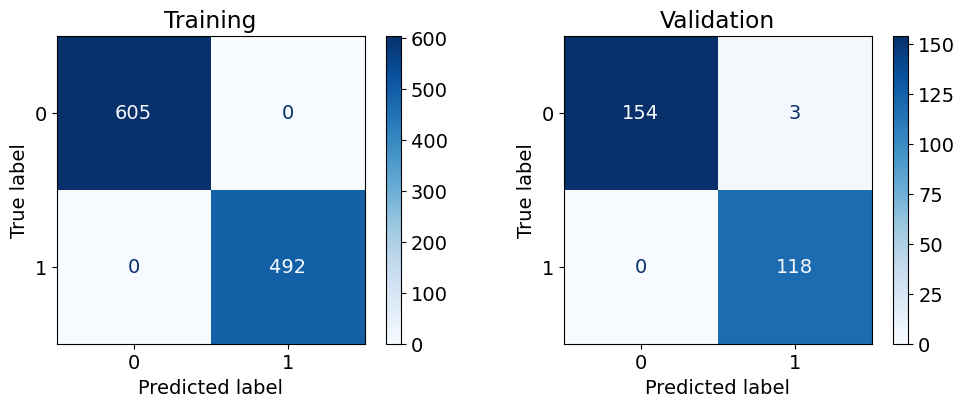

In [ ]:
plt.rcParams.update({'font.size': 14}); fig, ax = plt.subplots(1, 2, figsize = (12, 4))
ConfusionMatrixDisplay.from_estimator(gbt1, X_train, y_train, cmap = plt.cm.Blues, ax = ax[0])
ConfusionMatrixDisplay.from_estimator(gbt1, X_val, y_val, cmap = plt.cm.Blues, ax = ax[1])
ax[0].set_title('Training'); ax[1].set_title('Validation');

# Task 6
### Gradient Boosted Tree Model - 2
- Tune the gradient boosted tree model on number of estimators and learning rate
- Visualise the confusion matrices for the training and validation sets

In [ ]:
gbt_model = AdaBoostClassifier(random_state = 0, algorithm = 'SAMME')
param_grid = {'n_estimators': np.arange(25, 125, 25), 'learning_rate': [0.01, 0.1, 1]}
gbt_gscv = GridSearchCV(estimator = gbt_model, param_grid = param_grid, scoring = 'f1', cv = 5, verbose = 3)
gbt2 = gbt_gscv.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV 1/5] END learning_rate=0.01, n_estimators=25;, score=0.863 total time=   0.0s
[CV 2/5] END learning_rate=0.01, n_estimators=25;, score=0.809 total time=   0.0s
[CV 3/5] END learning_rate=0.01, n_estimators=25;, score=0.868 total time=   0.0s
[CV 4/5] END learning_rate=0.01, n_estimators=25;, score=0.849 total time=   0.0s
[CV 5/5] END learning_rate=0.01, n_estimators=25;, score=0.794 total time=   0.0s
[CV 1/5] END learning_rate=0.01, n_estimators=50;, score=0.863 total time=   0.0s
[CV 2/5] END learning_rate=0.01, n_estimators=50;, score=0.809 total time=   0.0s
[CV 3/5] END learning_rate=0.01, n_estimators=50;, score=0.834 total time=   0.1s
[CV 4/5] END learning_rate=0.01, n_estimators=50;, score=0.849 total time=   0.0s
[CV 5/5] END learning_rate=0.01, n_estimators=50;, score=0.794 total time=   0.0s
[CV 1/5] END learning_rate=0.01, n_estimators=75;, score=0.863 total time=   0.1s
[CV 2/5] END learning_rate=0.01, n_es

In [ ]:
best_n_estimators = gbt2.best_params_['n_estimators']
best_learning_rate = gbt2.best_params_['learning_rate']
print('The optimal value of n_estimators is', best_n_estimators)
print('The optimal value of learning_rate is', best_learning_rate)

The optimal value of n_estimators is 100
The optimal value of learning_rate is 1


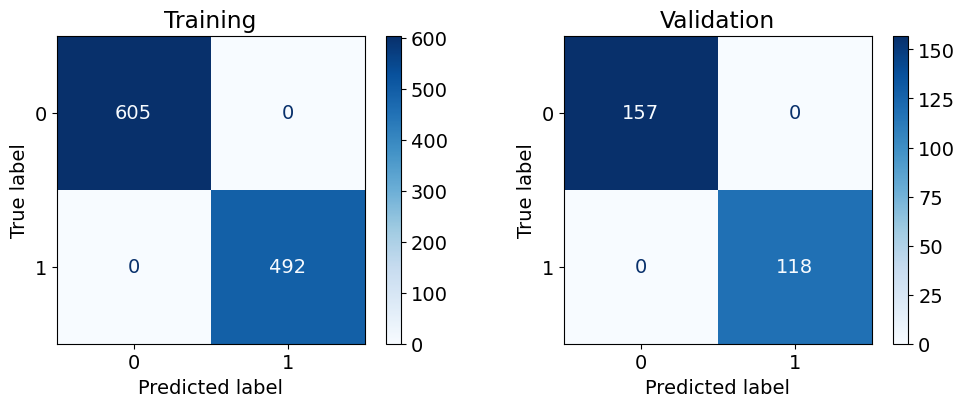

In [ ]:
plt.rcParams.update({'font.size': 14}); fig, ax = plt.subplots(1, 2, figsize = (12, 4))
ConfusionMatrixDisplay.from_estimator(gbt2, X_train, y_train, cmap = plt.cm.Blues, ax = ax[0])
ConfusionMatrixDisplay.from_estimator(gbt2, X_val, y_val, cmap = plt.cm.Blues, ax = ax[1])
ax[0].set_title('Training'); ax[1].set_title('Validation');

# Task 7
### Comparing the models
- Generate predicted class labels and predicted probabilities for all the models on the training and validation datasets, compute multiple performance metrics, and summarise the results in a comparison table
- Plot and compare the training and validation ROC curves for both decision tree models using their predicted probabilities

In [ ]:
models = [tree_model_1, tree_model_2, rf1, rf2, gbt1, gbt2]
modelnames = ['tree_model_1', 'tree_model_2', 'rf1', 'rf2', 'gbt1', 'gbt2']
train_probabilities = [None] * len(models); val_probabilities = [None] * len(models)
train_y_pred = [None] * len(models); val_y_pred = [None] * len(models)
train_acc = [None] * len(models); val_acc = [None] * len(models)
train_sens = [None] * len(models); val_sens = [None] * len(models)
train_spec = [None] * len(models); val_spec = [None] * len(models)
train_prec = [None] * len(models); val_prec = [None] * len(models)
train_f1 = [None] * len(models); val_f1 = [None] * len(models)
train_auc = [None] * len(models); val_auc = [None] * len(models)
i = -1
for model in models:
    i = i + 1
    train_probabilities[i] = models[i].predict_proba(X_train)[:, 1]; val_probabilities[i] = models[i].predict_proba(X_val)[:, 1]
    train_y_pred[i] = models[i].predict(X_train); val_y_pred[i] = models[i].predict(X_val)
    train_acc[i] = accuracy_score(y_train, train_y_pred[i]); val_acc[i] = accuracy_score(y_val, val_y_pred[i])
    train_sens[i] = recall_score(y_train, train_y_pred[i]); val_sens[i] = recall_score(y_val, val_y_pred[i])
    train_spec[i] = recall_score(y_train, train_y_pred[i], pos_label = 0); val_spec[i] = recall_score(y_val, val_y_pred[i], pos_label = 0)
    train_prec[i] = precision_score(y_train, train_y_pred[i]); val_prec[i] = precision_score(y_val, val_y_pred[i])
    train_f1[i] = f1_score(y_train, train_y_pred[i]); val_f1[i] = f1_score(y_val, val_y_pred[i])
    train_auc[i] = roc_auc_score(y_train, train_probabilities[i]); val_auc[i] = roc_auc_score(y_val, val_probabilities[i])
modelcompare = pd.DataFrame(data = {'Training Accuracy': train_acc,
                                    'Validation Accuracy': val_acc,
                                    'Training Sensitivity': train_sens,
                                    'Validation Sensitivity': val_sens,
                                    'Training Specificity': train_spec,
                                    'Validation Specificity': val_spec,
                                    'Training Precision': train_prec,
                                    'Validation Precision': val_prec,
                                    'Training F1 Score': train_f1,
                                    'Validation F1 Score': val_f1,
                                    'Training ROC AUC Score': train_auc,
                                    'Validation ROC AUC Score': val_auc},
                            index = modelnames)
modelcompare

,Training Accuracy,Validation Accuracy,Training Sensitivity,Validation Sensitivity,Training Specificity,Validation Specificity,Training Precision,Validation Precision,Training F1 Score,Validation F1 Score,Training ROC AUC Score,Validation ROC AUC Score
tree_model_1,1.000000,0.992727,1.000000,1.000000,1.000000,0.987261,1.000000,0.983333,1.000000,0.991597,1.000000,0.993631
tree_model_2,0.993619,0.985455,0.995935,0.983051,0.991736,0.987261,0.989899,0.983051,0.992908,0.983051,0.999815,0.992929
rf1,1.000000,0.989091,1.000000,0.991525,1.000000,0.987261,1.000000,0.983193,1.000000,0.987342,1.000000,0.999784
rf2,0.999088,0.985455,1.000000,0.983051,0.998347,0.987261,0.997972,0.983051,0.998985,0.983051,1.000000,0.999568
gbt1,1.000000,0.989091,1.000000,1.000000,1.000000,0.980892,1.000000,0.975207,1.000000,0.987448,1.000000,0.999838
gbt2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


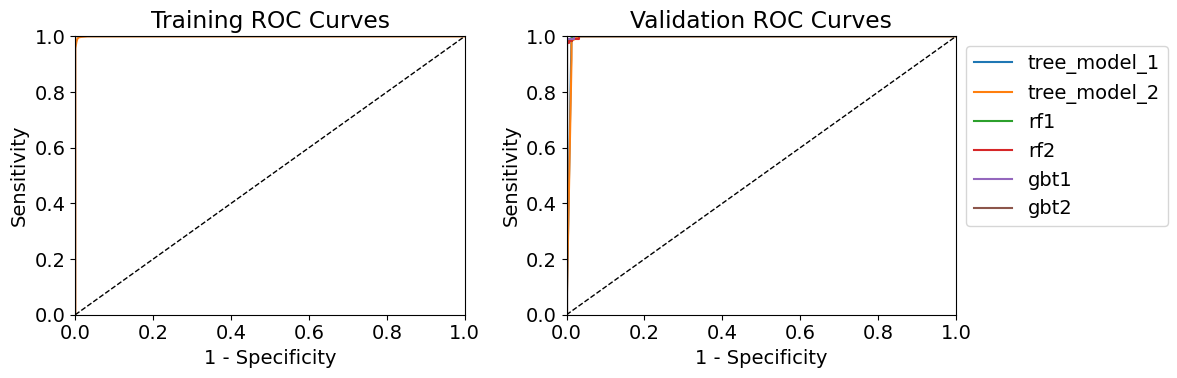

In [ ]:
train_1_spec = [None] * len(models); train_sens = [None] * len(models)
val_1_spec = [None] * len(models); val_sens   = [None] * len(models)
for i in range(len(models)):
    fpr_tr, tpr_tr, _ = roc_curve(y_train, train_probabilities[i])
    fpr_va, tpr_va, _ = roc_curve(y_val, val_probabilities[i])
    train_1_spec[i] = fpr_tr; train_sens[i] = tpr_tr
    val_1_spec[i] = fpr_va; val_sens[i] = tpr_va
plt.figure(figsize = (12, 4))
colorlist = sns.color_palette(n_colors = len(models))
ax1 = plt.subplot(1, 2, 1)
for i in range(len(models)): ax1.plot(train_1_spec[i], train_sens[i], color = colorlist[i])
ax1.plot([0, 1], [0, 1], 'k--', linewidth = 1)
ax1.set_xlabel('1 - Specificity'); ax1.set_ylabel('Sensitivity'); ax1.set_title('Training ROC Curves')
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
ax2 = plt.subplot(1, 2, 2)
for i in range(len(models)): ax2.plot(val_1_spec[i], val_sens[i], color = colorlist[i], label = modelnames[i])
ax2.plot([0, 1], [0, 1], 'k--', linewidth = 1)
ax2.set_xlabel('1 - Specificity'); ax2.set_ylabel('Sensitivity'); ax2.set_title('Validation ROC Curves')
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.legend(bbox_to_anchor = (1, 1))
plt.tight_layout();